# Introduction to RadiationDetectorDSP with Julia
This notebooks contains basic information on how to use the [RadiationDetectorDSP.jl](https://github.com/JuliaPhysics/RadiationDetectorDSP.jl) for DSP processing of HPGe detectors.

First you should create an environment and load the package:

```julia
import Pkg; Pkg.add("RadiationDetectorDSP#main")
using RadiationDetectorDSP
```
If you have already an environment, you can also include there.

In [1]:
import Pkg; Pkg.activate("/home/iwsatlas1/henkes/legend/julia/legend-julia-dsp-scripts")
using RadiationDetectorDSP

  Activating project at `~/legend/julia/legend-julia-dsp-scripts`


For this example, I use a test data file from LEGEND-200 which is located at `/remote/ceph2/group/legendex/data/l60/r025/cal/tier1/tier1_l60-p01-r025-cal-20220909T190252Z.lh5`. With the `LHDataStore` function from the [LEGENDHDF5](https://github.com/legend-exp/LegendHDF5IO.jl) package, you can load and open the file: 

*For the example, I only loaded the first 1000 events in the key `ORFlashCamADCWaveform` which is LEGEND specific and can be ignored for other data files.*

In [3]:
using LegendHDF5IO
testdata = LHDataStore("/remote/ceph2/group/legendex/data/l60/r025/cal/tier1/tier1_l60-p01-r025-cal-20220909T190252Z.lh5", "r")["ORFlashCamADCWaveform"][1:1000]
testdata[1]

(packet_id = 0x00000004, eventnumber = 0, timestamp = 1.662750177526872e9 s, runtime = 0.2580768 s, numtraces = 1, tracelist = Int16[], baseline = 0x3a8e, daqenergy = 0x5c90, channel = 0x00000002, ts_pps = 0, ts_ticks = 64519200, ts_maxticks = 249999999, to_mu_sec = 1662750177, to_mu_usec = 268795, to_master_sec = 1662750177, to_dt_mu_usec = 268795, to_abs_mu_usec = 268795, to_start_sec = 0, to_start_usec = 254543, dr_start_pps = 0, dr_start_ticks = 0, dr_stop_pps = 0, dr_stop_ticks = 64372074, dr_maxticks = 249999999, deadtime = 0.0, waveform = RadiationDetectorSignals.RDWaveform{Unitful.Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, UInt16, StepRangeLen{Unitful.Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Unitful.Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Unitful.Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Int64}, Vector{UInt16}}((0.0:16.0:131056.0) ns, UInt16[0x3a92, 0x3a81, 0x3a8b, 0x3a8e, 0x3a8b, 0x3a96, 0x3ab0, 0x3ab8, 

In [5]:
testdata.waveform[1]

RadiationDetectorSignals.RDWaveform{Unitful.Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, UInt16, StepRangeLen{Unitful.Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Unitful.Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Unitful.Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Int64}, SubArray{UInt16, 1, Matrix{UInt16}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}((0.0:16.0:131056.0) ns, UInt16[0x3a92, 0x3a81, 0x3a8b, 0x3a8e, 0x3a8b, 0x3a96, 0x3ab0, 0x3ab8, 0x3acc, 0x3ac9  …  0x7008, 0x700e, 0x7012, 0x7022, 0x703c, 0x7042, 0x702e, 0x7031, 0x702b, 0x7006])

Now, you can get the waveforms with

In [7]:
wvfs = testdata.waveform
wvfs[1]

RadiationDetectorSignals.RDWaveform{Unitful.Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, UInt16, StepRangeLen{Unitful.Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Unitful.Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Unitful.Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Int64}, SubArray{UInt16, 1, Matrix{UInt16}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}((0.0:16.0:131056.0) ns, UInt16[0x3a92, 0x3a81, 0x3a8b, 0x3a8e, 0x3a8b, 0x3a96, 0x3ab0, 0x3ab8, 0x3acc, 0x3ac9  …  0x7008, 0x700e, 0x7012, 0x7022, 0x703c, 0x7042, 0x702e, 0x7031, 0x702b, 0x7006])

To get a first look at the waveform, just plot the first 10 waveforms:

*If you want more fany plotting, you can use `plotyjs()`, but don't tell Oli ;)

In [8]:
using Plots 
# plotlyjs()

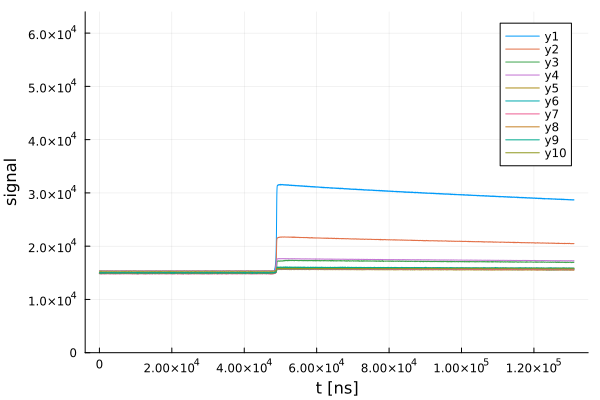

In [22]:
plot(wvfs[1:10])
# xlims!(0, 200)
ylims!(0, 64000)

First, you need to get shift the waveform down by substracting the baseline. Here, you can either use the `signalstats` function which calculates baseline mean, std and slope in a window you can define. With the `Unitful` package, you can write the window in the form of µs.

In [23]:
using Unitful
blstats = signalstats.(wvfs, 0u"µs", 39u"µs")

1000-element StructArray(::Vector{Float64}, ::Vector{Float64}, ::Vector{Quantity{Float64, 𝐓^-1, Unitful.FreeUnits{(ns^-1,), 𝐓^-1, nothing}}}, ::Vector{Float64}) with eltype NamedTuple{(:mean, :sigma, :slope, :offset), Tuple{Float64, Float64, Quantity{Float64, 𝐓^-1, Unitful.FreeUnits{(ns^-1,), 𝐓^-1, nothing}}, Float64}}:
 (mean = 14989.007383100903, sigma = 33.67055482378433, slope = -1.7955500291971465e-5 ns^-1, offset = 14989.357443534594)
 (mean = 14903.22272354389, sigma = 18.125282505727668, slope = -9.512482239540761e-5 ns^-1, offset = 14905.077277081311)
 (mean = 14886.067268252667, sigma = 27.282670715979066, slope = 0.0002846205160766312 ns^-1, offset = 14880.518306671238)
 (mean = 15384.950779327319, sigma = 12.487632822928408, slope = 2.8346646755499738e-5 ns^-1, offset = 15384.398133102173)
 (mean = 14920.270303527483, sigma = 14.93841431624656, slope = -6.742706268473691e-6 ns^-1, offset = 14920.401759328894)
 (mean = 14966.015176374078, sigma = 29.279244780199896, slope = 

In [25]:
blstats.mean[1]

14989.007383100903

Now, you can substract the baseline mean from the waveforms with the `shift_waveform` function:

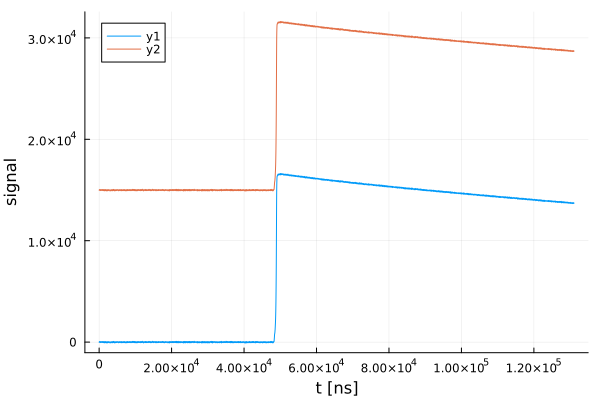

In [26]:
wvfs_bl = shift_waveform.(wvfs, -blstats.mean)
plot(wvfs_bl[1])
plot!(wvfs[1])

Next, you can deconvolute the waveform to remove the electronic response of the RC-feedback loop in the Charge Sensitive Amplifier (CSA).
If you have the deacy time constant extracted, you can perform the deconvolution with the `InvCRFilter` and the decay time constant as argument.

*In the example, I use a arbitrary fixed decay time constant of 450µs.*

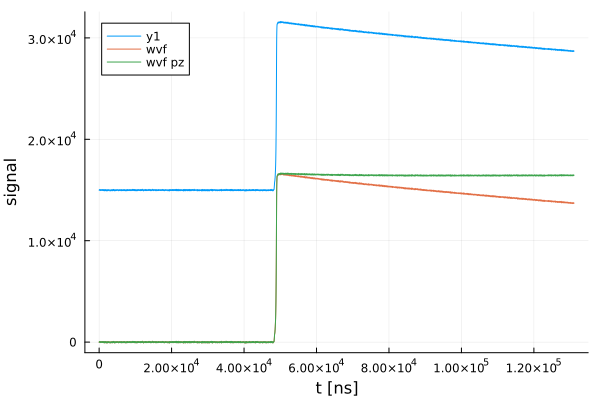

In [28]:
τ = 450u"µs"
deconv_flt = InvCRFilter(τ)
wvfs_pz = deconv_flt.(wvfs_bl)

plot(wvfs[1])
plot!(wvfs_bl[1], label="wvf")
plot!(wvfs_pz[1], label="wvf pz")

If you want to determine the $t_0$ point of the start of the drift of the charges, you can perform this with a asymetrical trapezoidal charge filter with steep rise, short flat top and long fall time. The filter is defined with the `TrapezoidalChargeFilter` and the filter parameters. In addition, the waveform is truncated with a `TruncateFilter` to get rid of the tail.

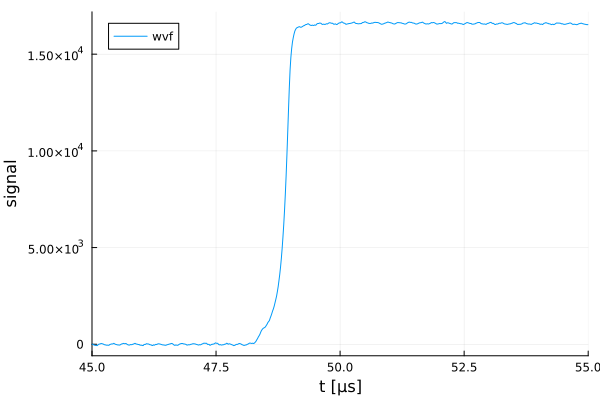

In [34]:
using IntervalSets
# define filters
uflt_asy_t0 = TrapezoidalChargeFilter(40u"ns", 100u"ns", 2000u"ns")
uflt_trunc_t0 = TruncateFilter(0u"µs"..60u"µs")

# apply filter to waveforms
wvfs_flt_asy_t0 = uflt_asy_t0.(uflt_trunc_t0.(wvfs_pz))

# plot waveform and filter
plot(u"µs", Unitful.NoUnits)
plot!(wvfs_pz[1], label="wvf")
# plot!(wvfs_flt_asy_t0[1], label="filtered waveform")
xlims!(45, 55)

The $t_0$ point can then be calculated with a intersect at a fixed y-location where the waveform stays at least a certain amount of time above this threshold.

*In our example, the threshold is 5 ADC.*

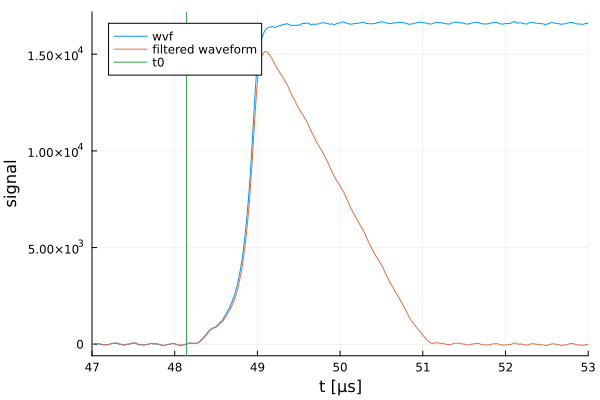

In [32]:
flt_intersec_t0 = Intersect(mintot = 600u"ns")
t0 = uconvert.(u"µs", flt_intersec_t0.(wvfs_flt_asy_t0, 5).x)
plot(u"µs", Unitful.NoUnits)
plot!(wvfs_pz[1], label="wvf")
plot!(wvfs_flt_asy_t0[1], label="filtered waveform")
vline!([t0[1]], label="t0")
xlims!(47, 53)

Following, to get the energy, you have to apply a energy filter. The simplest is the trapezoidal filter, but also the cusp and Zac filter are implemented in RaditionDetectorDSP. To apply a filter, you have to construct it first with its rise and flat top time and then apply it to the waveforms. 

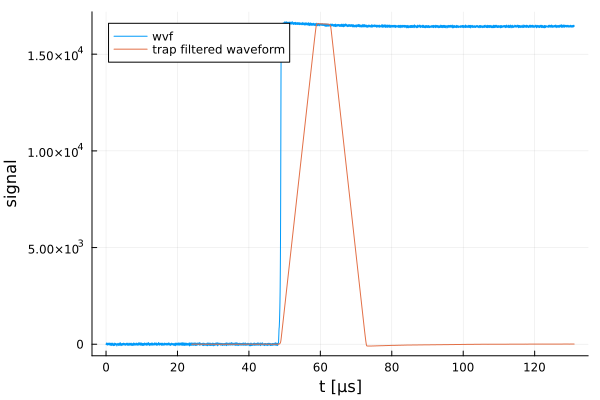

In [29]:
uflt_10410 = TrapezoidalChargeFilter(10u"µs", 4u"µs")
wvfs_flt_10410 = uflt_10410.(wvfs_pz)
plot(u"µs", Unitful.NoUnits)
plot!(wvfs_pz[1], label="wvf")
plot!(wvfs_flt_10410[1], label="trap filtered waveform")

The energy is can then be extracted at a fixed loaction at the flat top relative to $t_0$ at $t_0 + t_{rise} + 0.5 \cdot t_{flat}$. For higher precision, the `SignalEstimator` can be used to do a Polynominal Regression and interpolate in a window.

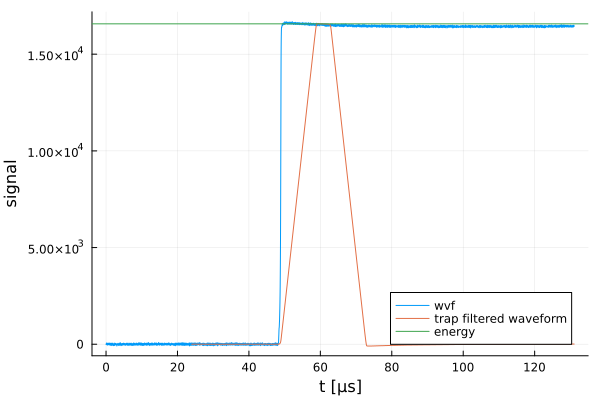

In [33]:
e_10410 = SignalEstimator(PolynomialDNI(3, 100u"ns")).(wvfs_flt_10410, t0 .+ 12u"µs")
plot(u"µs", Unitful.NoUnits)
plot!(wvfs_pz[1], label="wvf")
plot!(wvfs_flt_10410[1], label="trap filtered waveform")
hline!([e_10410[1]], label="energy", line_width=5, legend=:bottomright)

Finally, to extract the current for Pulse Shape analysis (PSA), you can use a Savitzky-Golay for waveform smoothng and take the maximum of the derivative as $A$ parameter for the $A/E$ analysis.

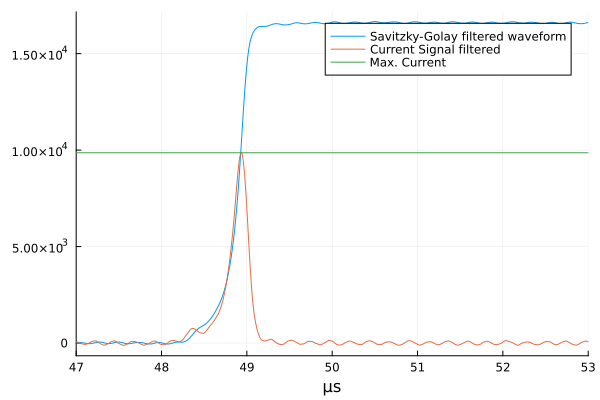

In [16]:
sgflt_deriv = SavitzkyGolayFilter(180u"ns", 2, 1)
sgflt_noderiv = SavitzkyGolayFilter(180u"ns", 2, 0)
wvfs_sgflt_deriv = sgflt_deriv.(wvfs_pz)
wvfs_sgflt_noderiv = sgflt_noderiv.(wvfs_pz)
current_max = maximum.(wvfs_sgflt_deriv.signal)[1]
wvf_max = maximum.(wvfs_sgflt_noderiv.signal)[1]
plot(u"µs", Unitful.NoUnits)
plot!(wvfs_sgflt_deriv[1].time, wvfs_sgflt_noderiv[1].signal, label="Savitzky-Golay filtered waveform")
plot!(wvfs_sgflt_deriv[1].time, wvfs_sgflt_deriv[1].signal*10, label="Current Signal filtered")
hline!([current_max*10], label="Max. Current", line_width=5, legend=:topright)
xlims!(47, 53)

To get $Q_{drift}$ parameter, the PZ-corrected waveforms are integrated from $t_0$ to $t_0 + 2.5\mu s$ and from $t_0 + 2.5\mu s$ $t_0 + 5\mu s$ and take the difference between the two areas. 

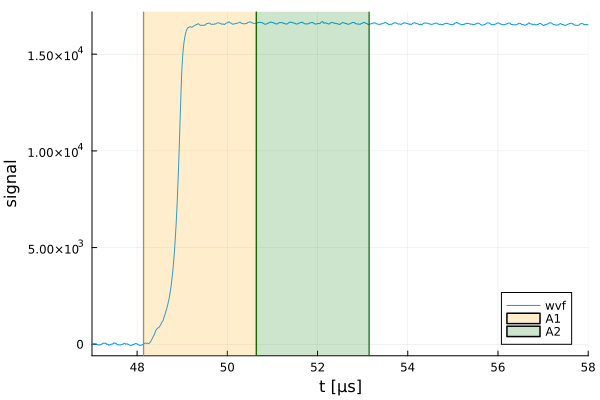

In [14]:
int_flt = IntegratorFilter(1)
wvfs_int = int_flt.(wvfs_pz)

area1 = SignalEstimator(PolynomialDNI(3, 100u"ns")).(wvfs_int, t0 .+ 2.5u"µs") .- SignalEstimator(PolynomialDNI(3, 100u"ns")).(wvfs_int, t0)
area2 = SignalEstimator(PolynomialDNI(3, 100u"ns")).(wvfs_int, t0 .+ 5u"µs")   .- SignalEstimator(PolynomialDNI(3, 100u"ns")).(wvfs_int, t0 .+ 2.5u"µs")
qdrift = area2 .- area1
plot(u"µs", Unitful.NoUnits)
plot!(wvfs_pz[1], label="wvf")
# plot!(wvfs_int[1], label="integrated waveform")
vline!([t0[1], t0[1] + 2.5u"µs"], label="", line_width=5, color=:orange)
vspan!([t0[1], t0[1] + 2.5u"µs"], fillrange=t0[1] + 2.5u"µs", lw=1.5, alpha=0.2, color=:orange, label="A1")
vline!([t0[1] + 2.5u"µs", t0[1] + 5u"µs"], label="", line_width=5, color=:green)
vspan!([t0[1] + 2.5u"µs", t0[1] + 5u"µs"], fillrange=wvfs_pz[1], lw=1.5, alpha=0.2, color=:green, label="A2")
xlims!(47, 58)